In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
df = pd.read_csv('match_data_v5.csv', header=None)
df.columns = [
    'matchId',
    'blueTeamControlWardsPlaced',
    'blueTeamWardsPlaced',
    'blueTeamTotalKills',
    'blueTeamDragonKills',
    'blueTeamHeraldKills',
    'blueTeamTowersDestroyed',
    'blueTeamInhibitorsDestroyed',
    'blueTeamTurretPlatesDestroyed',
    'blueTeamFirstBlood',
    'blueTeamMinionsKilled',
    'blueTeamJungleMinions',
    'blueTeamTotalGold',
    'blueTeamXp',
    'blueTeamTotalDamageToChamps',
    'redTeamControlWardsPlaced',
    'redTeamWardsPlaced',
    'redTeamTotalKills',
    'redTeamDragonKills',
    'redTeamHeraldKills',
    'redTeamTowersDestroyed',
    'redTeamInhibitorsDestroyed',
    'redTeamTurretPlatesDestroyed',
    'redTeamMinionsKilled',
    'redTeamJungleMinions',
    'redTeamTotalGold',
    'redTeamXp',
    'redTeamTotalDamageToChamps',
    'blueWin',
    'idk'
]
df = df.drop(columns=['idk'])
df = df.drop(index=0)

In [19]:
print("Primele rânduri din meciurile de LoL:")
display(df.head())
print("\nInformații despre structura datelor:")
df.info()
print(df.isnull().sum())

Primele rânduri din meciurile de LoL:


,matchId,blueTeamControlWardsPlaced,blueTeamWardsPlaced,blueTeamTotalKills,blueTeamDragonKills,blueTeamHeraldKills,blueTeamTowersDestroyed,blueTeamInhibitorsDestroyed,blueTeamTurretPlatesDestroyed,blueTeamFirstBlood,...,redTeamHeraldKills,redTeamTowersDestroyed,redTeamInhibitorsDestroyed,redTeamTurretPlatesDestroyed,redTeamMinionsKilled,redTeamJungleMinions,redTeamTotalGold,redTeamXp,redTeamTotalDamageToChamps,blueWin
1,EUW1_6882489515',2.0,23.0,4.0,2.0,0.0,0.0,0.0,7.0,0.0,...,0.0,2.0,0.0,1.0,400.0,94.0,29637.0,32613.0,27239.0,1.0
2,EUW1_6882416210',2.0,46.0,12.0,1.0,0.0,1.0,0.0,10.0,0.0,...,0.0,1.0,0.0,4.0,373.0,76.0,28970.0,30320.0,36585.0,0.0
3,EUW1_6881092720',2.0,19.0,13.0,0.0,0.0,0.0,0.0,11.0,0.0,...,0.0,2.0,0.0,3.0,340.0,84.0,30510.0,29464.0,42984.0,0.0
4,EUW1_6879405717',3.0,28.0,8.0,0.0,1.0,1.0,0.0,9.0,1.0,...,0.0,0.0,0.0,5.0,378.0,87.0,25157.0,31069.0,28229.0,0.0
5,EUW1_6879389461',3.0,30.0,11.0,1.0,1.0,1.0,0.0,7.0,0.0,...,0.0,1.0,0.0,5.0,382.0,96.0,26052.0,29475.0,19245.0,1.0



Informații despre structura datelor:
<class 'pandas.DataFrame'>
RangeIndex: 24225 entries, 1 to 24225
Data columns (total 29 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   matchId                        24225 non-null  str    
 1   blueTeamControlWardsPlaced     24225 non-null  float64
 2   blueTeamWardsPlaced            24225 non-null  float64
 3   blueTeamTotalKills             24225 non-null  float64
 4   blueTeamDragonKills            24225 non-null  float64
 5   blueTeamHeraldKills            24225 non-null  float64
 6   blueTeamTowersDestroyed        24225 non-null  float64
 7   blueTeamInhibitorsDestroyed    24225 non-null  float64
 8   blueTeamTurretPlatesDestroyed  24225 non-null  float64
 9   blueTeamFirstBlood             24225 non-null  float64
 10  blueTeamMinionsKilled          24225 non-null  float64
 11  blueTeamJungleMinions          24225 non-null  float64
 12  blueTeamTotalGold  

Corelația fiecărei variabile cu victoria (blueWin):


blueWin                          1.000000
blueTeamTotalGold                0.454814
blueTeamXp                       0.440802
blueTeamTotalKills               0.392896
redTeamTurretPlatesDestroyed     0.327606
blueTeamDragonKills              0.317602
blueTeamTowersDestroyed          0.316028
blueTeamTotalDamageToChamps      0.289770
blueTeamMinionsKilled            0.247761
blueTeamJungleMinions            0.209993
blueTeamFirstBlood               0.173681
blueTeamHeraldKills              0.108177
blueTeamControlWardsPlaced       0.060471
blueTeamInhibitorsDestroyed      0.037800
blueTeamWardsPlaced              0.006818
redTeamWardsPlaced              -0.000419
redTeamInhibitorsDestroyed      -0.023065
redTeamControlWardsPlaced       -0.052634
redTeamHeraldKills              -0.116562
redTeamJungleMinions            -0.209769
blueTeamTurretPlatesDestroyed   -0.261331
redTeamMinionsKilled            -0.266819
redTeamTowersDestroyed          -0.267682
redTeamTotalDamageToChamps      -0

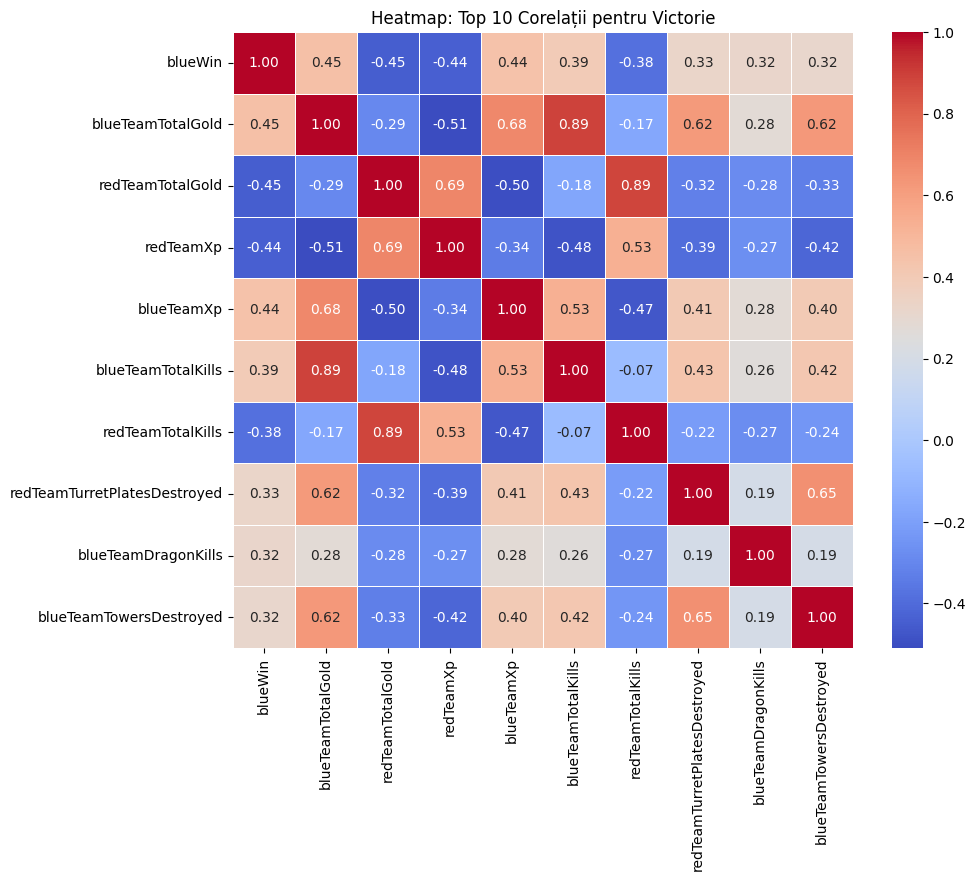

In [20]:
df_numeric = df.select_dtypes(include=['number', 'float64', 'int64'])

print("Corelația fiecărei variabile cu victoria (blueWin):")
corelatii_victorie = df_numeric.corr()['blueWin'].sort_values(ascending=False)
display(corelatii_victorie)


plt.figure(figsize=(10, 8))

top_variabile = df_numeric.corr()['blueWin'].abs().sort_values(ascending=False).head(10).index
matrice_corelatie_top = df_numeric[top_variabile].corr()

sns.heatmap(matrice_corelatie_top, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Heatmap: Top 10 Corelații pentru Victorie')
plt.show()

C:\Users\andic\AppData\Local\Temp\ipykernel_24316\824930742.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Rezultat', y='blueTeamTotalGold', data=df_numeric, palette={'Victorie (Blue)': '#3498db', 'Înfrângere (Red)': '#e74c3c'})


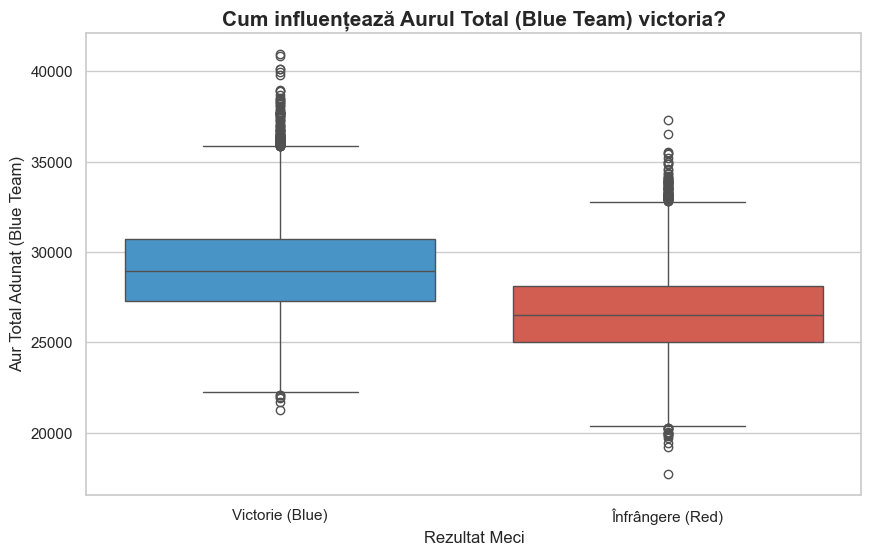

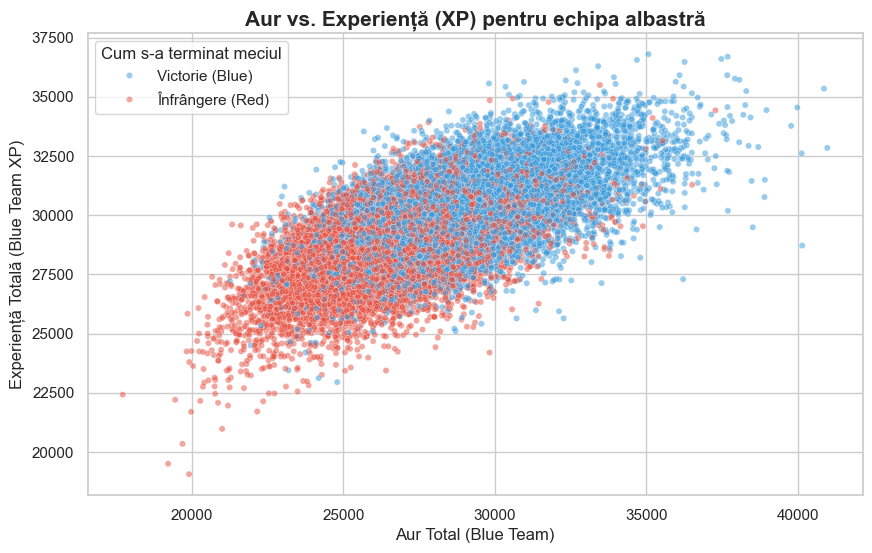

In [ ]:

df_numeric['Rezultat'] = df_numeric['blueWin'].map({1.0: 'Victorie (Blue)', 0.0: 'Înfrângere (Red)'})


sns.set_theme(style="whitegrid")


plt.figure(figsize=(10, 6))

sns.boxplot(x='Rezultat', y='blueTeamTotalGold', data=df_numeric, palette={'Victorie (Blue)': '#3498db', 'Înfrângere (Red)': '#e74c3c'})
plt.title('Cum influențează Aurul Total (Blue Team) victoria?', fontsize=15, fontweight='bold')
plt.xlabel('Rezultat Meci', fontsize=12)
plt.ylabel('Aur Total Adunat (Blue Team)', fontsize=12)
plt.show()


plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='blueTeamTotalGold', 
    y='blueTeamXp', 
    hue='Rezultat', 
    data=df_numeric, 
    palette={'Victorie (Blue)': '#3498db', 'Înfrângere (Red)': '#e74c3c'}, 
    alpha=0.5, 
    s=20 
)
plt.title('Aur vs. Experiență (XP) pentru echipa albastră', fontsize=15, fontweight='bold')
plt.xlabel('Aur Total (Blue Team)', fontsize=12)
plt.ylabel('Experiență Totală (Blue Team XP)', fontsize=12)
plt.legend(title='Cum s-a terminat meciul')
plt.show()